# **Laboratorio 6: Una introducción al algoritmo de Descenso de Gradiente**
**Facultad de ingeniería**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2440** Fundamentos de Machine Learning

**Nombres de los integrantes**

1.   Juan Pablo Castro
2.   Santiago Casasbuenas
2.   Ana Cristina Rodríguez

**Número del grupo**

*9*


# **Descenso de Gradiente**

Gradient Descent en inglés o simplemente GD, se trata de un algoritmo de optimización de primer orden con la capacidad de hallar valores mínimos en una amplia gama de problemas de optimización libre (sin restricciones).

**1. Fundamento teórico**

El concepto fundamental que soporta el funcionamiento del algoritmo es el de *gradiente de una función* $\nabla_{f}$. Recordemos de Calculo Vectorial que el gradiente $\nabla_{f}$ de una función $f: \mathbb{R^n} \rightarrow \mathbb{R}$ diferenciable se trata de un vector n-dimensional que apunta en la dirección que máximiza el cambio, la dirección de máximo crecimiento de la función, perpendicular a las curvas de nivel y cuya magnitud representa la pendiente entre dos curvas de nivel en la dirección de máximo crecimiento (es mayor conforme más cerca entre sí estan las curvas de nivel es decir, entre mayor es el cambio de altura entre dos puntos). Bajo estas propiedades, si recorremos la función desde un punto arbitrario en su dominio siguiendo la dirección del gradiente, vamos a construir el camino más corto que conduce al valor máximo de la función.

**2. Algoritmo de Descenso de Gradiente**

A partir de estas propiedades del gradiente, el algoritmo de Descenso de Gradiente propone hallar el mínimo de una función $f: \mathbb{R^n} \rightarrow \mathbb{R}$ diferenciable, recorriendo la función en la dirección opuesta a la que apunta el gradiente (es decir, la dirección de mínimo crecimiento), de esta forma podemos construir un camino, el más corto, que conduce al valor mínimo de la función:

\begin{align*}
x_{n+1} = x_{n} - \nabla_f(x_{n})
\end{align*}

Este algoritmo nos conduce inevitablemente al mínimo de la función. No obstante, dependiendo el comportamiento de la función, el gradiente puede ser inestable (variar de valores muy grandes a muy pequeños) lo que dificulta al algoritmo converger de forma eficiente al mínimo. Por esta razón resulta conveniente agregar un factor que escale el valor del gradiente y que permita controlar la longitud en cada paso del recorrido:

\begin{align*}
x_{n+1} = x_{n} - \alpha \nabla_f(x_{n})
\end{align*}

El factor $\alpha$ es un número real positivo que se conoce como *tasa de aprendizaje (learning rate en inglés)* y es un hiperparámetro crítico en el algoritmo, puesto que determina su velocidad de convergencia, la estabilidad del proceso y puede afectar el valor mínimo hallado.

Veamos paso a paso como opera el algoritmo:

1. **Iniciamos desde un punto de partida ($x_0$)**: Este punto inicial es arbitrario, un punto cualquiera en el dominio de la función. Su elección se hace crítica cuando la función no es convexa o tiene varios mínimos locales.

2. **Calculamos el gradiente en este punto $\nabla_f(x_{0})$**: Calculamos el vector gradiente de la función objetivo $\nabla_{f}$ y lo evaluamos en el punto de partida $\nabla_{f}(x_{0})$. 

3. **Elegimos una tasa de aprendizaje adecuada ($\alpha$)**: Su valor es muy crítico: un valor de $\alpha$ muy pequeño implica una convergencia muy lenta, por otro lado, un valor de $\alpha$ muy grande podría saltar muchos detalles de la geometría de la función y nos haría perder el rumbo o incluso pasar por encima del mínimo, haciendo que el algoritmo nunca converja.

4. **Hallamos un nuevo punto inicial ($x_1$)**: Al tomar la diferencia $x_0 - \alpha \nabla_{f}(x_{0})$ damos un paso en dirección al mínimo que nos lleva a un nuevo punto $x_1$ que se encuentra más cerca de éste valor:

\begin{align*}
x_{1} = x_{0} - \alpha \nabla_f(x_{0})
\end{align*}

5. **Iteramos**: Tomando $x_{1}$ como nuevo punto inicial repetimos el proceso anterior, que continua siguiendo el algoritmo:

\begin{align*}
x_{n+1} = x_{n} - \alpha \nabla_f(x_{n})
\end{align*}

Hasta que se observa que la variación entre cada punto nuevo se encuentra por debajo de una tolerancia definida, allí el método finaliza y tomamos el último valor $x_{n+1}$ como el mínimo de la función.


A continuación se presenta un pseudoalgoritmo para el método de Descenso de Gradiente, donde $x[k]$ es un vector en $R^n$ que corresponde al resultado de la iteración $k$, $\nabla_f$ es el gradiente de la función y $\alpha$ es la tasa de aprendizaje.

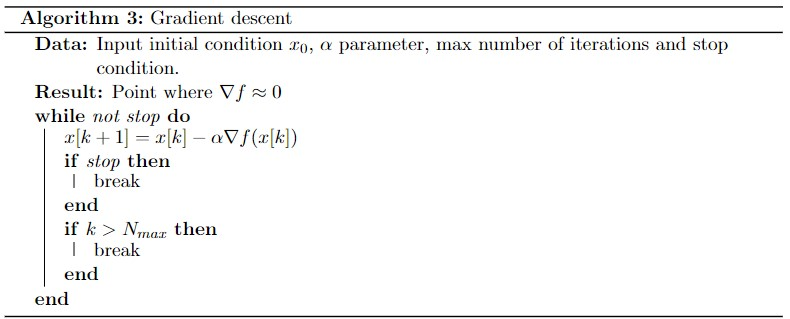

**1.1 Ejercicios**


- Se requiere resolver el siguiente problema de optimización libre:


  $$\min_x f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^TQ\mathbf{x}+B^T\mathbf{x}+C,   
  x \in R^2$$



- Donde:

$$
  Q = \begin{pmatrix}
  1 & 3 \\
  -2 & 1
  \end{pmatrix},
$$
$$
  B = \begin{pmatrix}
  1/2 \\
  1
  \end{pmatrix},
$$
$$
  C= 5,
$$
$$
  x= [x_1, x_2]^T
$$

1. ¿Cúal es la finalidad de encontrar un punto donde el gradiente de una función objetivo se anule en un contexto de optimización?

**Respuesta (Pregunta 1)**

La finalidad de encontrar un punto donde el gradiente se anula ($\nabla f(x)=0$) es identificar un **punto crítico o estacionario**, es decir, un punto en el que la función ya no presenta cambio local en ninguna dirección (condición de primer orden).

En optimización, esto es importante porque:

- Para funciones diferenciables, un mínimo o máximo local interior debe cumplir (en general) que $\nabla f(x)=0$.
- Estos puntos son **candidatos** a mínimo, máximo o punto de silla, por lo que luego deben clasificarse (por ejemplo, con la Hessiana).
- Si la función es **convexa** y diferenciable, cualquier punto con gradiente nulo corresponde al **mínimo global**.



2. Determine de forma **analítica** si el problema es convexo o no, en caso de serlo, calcule **analíticamente** el minimizador.

**Respuesta (Pregunta 2)**

Se tiene:

$$
f(\mathbf{x})=\frac{1}{2}\mathbf{x}^TQ\mathbf{x}+B^T\mathbf{x}+C,
\quad
Q=\begin{pmatrix}1 & 3\\-2 & 1\end{pmatrix},
\quad
B=\begin{pmatrix}1/2\\1\end{pmatrix}
$$

### 1. Convexidad del problema

Aunque $Q$ no es simétrica, la convexidad de la forma cuadrática depende de la **parte simétrica**:

$$
H = \frac{Q+Q^T}{2}
= \frac{1}{2}
\left(
\begin{pmatrix}1 & 3\\-2 & 1\end{pmatrix}
+
\begin{pmatrix}1 & -2\\3 & 1\end{pmatrix}
\right)
=
\begin{pmatrix}1 & 1/2\\1/2 & 1\end{pmatrix}
$$

La Hessiana de $f$ es precisamente $H$. Para verificar convexidad estricta en $\mathbb{R}^2$, revisamos que $H$ sea definida positiva:

- Menor principal de orden 1: $1 > 0$
- Determinante: $\det(H)=1-\frac{1}{4}=\frac{3}{4}>0$

Por lo tanto, $H \succ 0$ y el problema es **estrictamente convexo**. En consecuencia, existe un **único minimizador global**.

### 2. Cálculo analítico del minimizador

El gradiente es:

$$
\nabla f(\mathbf{x}) = H\mathbf{x}+B
= \begin{pmatrix}1 & 1/2\\1/2 & 1\end{pmatrix}
\begin{pmatrix}x_1\\x_2\end{pmatrix}
+
\begin{pmatrix}1/2\\1\end{pmatrix}
$$

Entonces:

$$
\nabla f(\mathbf{x}) =
\begin{pmatrix}
x_1 + \frac{1}{2}x_2 + \frac{1}{2}\\
\frac{1}{2}x_1 + x_2 + 1
\end{pmatrix}
$$

Igualando a cero:

$$
\begin{cases}
x_1 + \frac{1}{2}x_2 + \frac{1}{2} = 0 \\
\frac{1}{2}x_1 + x_2 + 1 = 0
\end{cases}
$$

Resolviendo el sistema:

$$
\boxed{\mathbf{x}^* = \begin{pmatrix}0\\-1\end{pmatrix}}
$$

(Valor mínimo correspondiente: $f(\mathbf{x}^*) = 9/2 = 4.5$).



3. Implemente una función que reciba como argumento un punto $[x_1, x_2]^T$ y retorne el vector gradiente evaluado en ese punto, para ello calcule teóricamente el gradiente de la forma cuadrática y agreguelo en la implementación. **Nota:** No puede usar librerias de cálculo simbólico.

In [5]:
# Solucion analitica:
# f(x) = 1/2 x^T Q x + B^T x + C  =>  grad f(x) = ((Q + Q^T)/2) x + B
# Para este problema: grad f([x1, x2]^T) = [x1 + 0.5*x2 + 0.5, 0.5*x1 + x2 + 1]^T

def gradiente_f(x):
    x1 = float(x[0])
    x2 = float(x[1])
    return [x1 + 0.5 * x2 + 0.5, 0.5 * x1 + x2 + 1.0]



4. Implemente una función que reciba como argumento un punto inicial $X_0$, un parámetro $\alpha > 0$ , un número máximo de pasos $N$ y un parámetro $\epsilon > 0$ que defina la tolerancia. Utilice como criterio de parada la expresión  $||x[k+1]-x[k]||_2 \leq ϵ$, así el algoritmo de Descenso de Gradiente converge si $x[k+1]$ es muy cercano a $x[k]$. La función debe retornar un diccionario con 4 elementos: el historial de los puntos por donde pasa el algoritmo (es decir, todos sus puntos $x[k]$), la función evaluada en cada punto $f(x[k])$, el punto $x_k$ que corresponde al valor mínimo y un booleano que indique si se superó el número máximo de pasos permitido (*True* si se superan los pasos, *False* en caso contrario).  

In [6]:
def f_cuadratica(x):
    # Evalua f(x) = 1/2 * x^T H x + B^T x + C con H simetrica.
    x1 = float(x[0])
    x2 = float(x[1])
    return 0.5 * (x1**2 + x1 * x2 + x2**2) + 0.5 * x1 + x2 + 5.0

def descenso_gradiente_tolerancia(X0, alpha, N, epsilon):
    # Inicializacion del algoritmo en el punto de partida.
    xk = [float(X0[0]), float(X0[1])]

    # Listas para guardar la trayectoria x[k] y f(x[k]).
    historial_x = [xk.copy()]
    historial_f = [f_cuadratica(xk)]

    # True si no se alcanza convergencia antes de N pasos.
    supero_max_pasos = True

    # Iteraciones de descenso de gradiente.
    for _ in range(int(N)):
        # Calcula gradiente y actualiza con x[k+1] = x[k] - alpha * grad f(x[k]).
        grad = gradiente_f(xk)
        xkp1 = [xk[0] - alpha * grad[0], xk[1] - alpha * grad[1]]

        # Guarda el nuevo punto y el valor de la funcion.
        historial_x.append(xkp1.copy())
        historial_f.append(f_cuadratica(xkp1))

        # Criterio de parada: ||x[k+1] - x[k]||_2 <= epsilon.
        paso = ((xkp1[0] - xk[0])**2 + (xkp1[1] - xk[1])**2) ** 0.5
        if paso <= epsilon:
            supero_max_pasos = False
            xk = xkp1
            break

        # Si no converge, el nuevo punto pasa a ser el actual.
        xk = xkp1

    # 5) Retorna lo solicitado en el enunciado.
    return {
        "historial_x": historial_x,
        "historial_f": historial_f,
        "x_min": xk,
        "supero_max_pasos": supero_max_pasos,
    }



5. Implemente una función con la misma estructura de la función del punto anterior pero que tome como criterio de parada $||∇f(x[k])||_2≤\epsilon$, es decir, el algoritmo se debe detener si la norma del gradiente es menor a la tolerancia definida. ¿Que implicaciones tiene esta nueva condición en el funcionamiento del algoritmo respecto a la condición del ejercicio anterior?

In [7]:
def descenso_gradiente_tolerancia_parada(X0, alpha, N, epsilon):
    # Inicializacion de punto de partida e historial.
    xk = [float(X0[0]), float(X0[1])]
    historial_x = [xk.copy()]
    historial_f = [f_cuadratica(xk)]

    # True si se consumen todos los pasos sin cumplir tolerancia.
    supero_max_pasos = True

    # Iteraciones de descenso de gradiente.
    for _ in range(int(N)):
        grad = gradiente_f(xk)

        # Criterio de parada del punto 5: ||grad f(x[k])||_2 <= epsilon.
        norma_grad = (grad[0] ** 2 + grad[1] ** 2) ** 0.5
        if norma_grad <= epsilon:
            supero_max_pasos = False
            break

        # Si aun no converge, actualiza x y guarda trayectoria.
        xkp1 = [xk[0] - alpha * grad[0], xk[1] - alpha * grad[1]]
        historial_x.append(xkp1.copy())
        historial_f.append(f_cuadratica(xkp1))
        xk = xkp1

    # Retorna el mismo formato de salida del enunciado.
    return {
        "historial_x": historial_x,
        "historial_f": historial_f,
        "x_min": xk,
        "supero_max_pasos": supero_max_pasos,
    }


6. Evalúe las funciones implementadas en los ejercicios 4 y 5 para calcular el posible minimizador local de la forma cuadrática suministrada considerando los siguientes parámetros:

  - $\epsilon = 0.1$
  - $n = 100$
  - $X_0 = [2,2]^T$

  Además, ambas funciones deben ser invocadas para tres valores distintos de la tasa de aprendizaje, $\alpha = [0.1, 0.5, 0.8]$

In [42]:
x0 = [2,2]
alpha = [0.1,0.5,0.8]
n = 100
epsilon = 0.1

def evaluar_descenso_gradiente(x0, alpha, n, epsilon):
    for i in alpha:
        print(f"EVALUACION PARA a={i}")

        # Metodo criterio movimiento
        cm = descenso_gradiente_tolerancia(x0, i, n, epsilon)
        print("---- Metodo de criterio movimiento ----")
        print ("historial X :" , cm["historial_x"])
        print ("historial f :" ,cm["historial_f"])
        print ("cantidad de iteraciones:", len(cm["historial_x"]) - 1)
        print ("X min :" ,cm["x_min"])
        print ("superó max pesos:" ,cm["supero_max_pasos"])

        # Metodo criterio gradiente
        cg = descenso_gradiente_tolerancia_parada(x0, i, n, epsilon)
        print("---- Metodo de criterio gradiente ----")
        print ("historial X :" , cg["historial_x"])
        print ("historial f :" ,cg["historial_f"])
        print ("cantidad de iteraciones:", len(cg["historial_x"]) - 1)
        print ("X min :" ,cg["x_min"])
        print ("superó max pesos:" ,cg["supero_max_pasos"])
        print("\n")

evaluar_descenso_gradiente(x0, alpha, n, epsilon)



EVALUACION PARA a=0.1
---- Metodo de criterio movimiento ----
historial X : [[2.0, 2.0], [1.65, 1.6], [1.355, 1.2575], [1.106625, 0.964], [0.8977625, 0.71226875], [0.7223728125, 0.49615374999999995], [0.57532784375, 0.3104197343749999], [0.45227407265625, 0.15061136874999992], [0.349516096953125, 0.012936528242187412], [0.2639176608457031, -0.10583292942968758], [0.19281754123261718, -0.20844551952900398], [0.13395806308580566, -0.29724184463773445], [0.0854243490091118, -0.3742155633282513]]
historial f : [14.0, 11.38625, 9.495621875000001, 8.1276631953125, 7.137526226152344, 6.420539658099072, 5.901061484109443, 5.524425024241482, 5.25111976704457, 5.052586881734366, 4.90818134421839, 4.802976954451979, 4.726180354353463]
cantidad de iteraciones: 12
X min : [0.0854243490091118, -0.3742155633282513]
superó max pesos: False
---- Metodo de criterio gradiente ----
historial X : [[2.0, 2.0], [1.65, 1.6], [1.355, 1.2575], [1.106625, 0.964], [0.8977625, 0.71226875], [0.7223728125, 0.4961537

7. En un figura de 2 columnas y 3 filas grafique las curvas de nivel de la forma cuadrática y las trayectorias de búsqueda del mínimizador que obtuvo como resultado en el punto anterior, para cada una de las tasas de aprendizaje. Agregue un título relacionado así como etiquetas en los ejes.

  **Hint:** Cada uno de sus subplots debería lucir *similar* al que se presenta a continuación:

  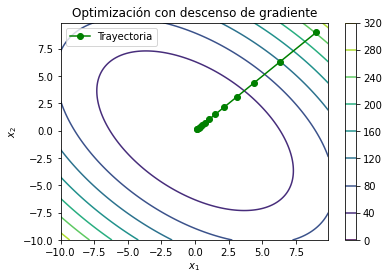

Text(0.5, 1.0, 'Descenso de Gradiente - Criterio Gradiente (a=0.8)')

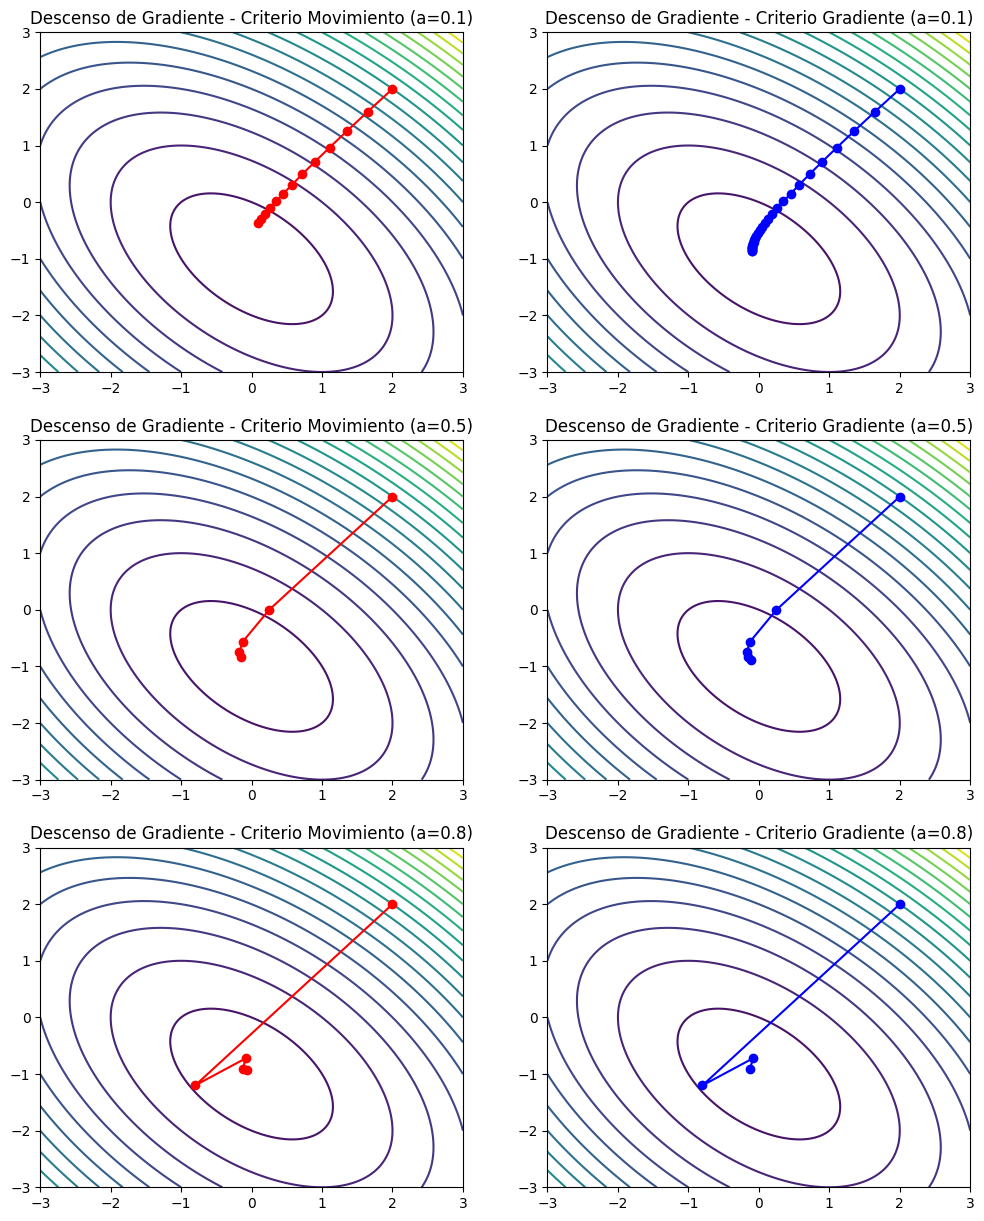

In [49]:
import matplotlib.pyplot as plt
import numpy as np

x0 = [2,2]
n = 100
epsilon = 0.1

fig, axs = plt.subplots(3, 2, figsize=(12,15))

#se sabe que el minimo esta en x* = [0, -1] y empezamos en x0 = [2, 2], entonces se grafica en un rango que incluya ambos puntos.
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
#organizamos en una matriz para evaluar la funcion en cada punto del plano.
X, Y = np.meshgrid(x,y)
#ahora evaluamos la funcion en cada punto del plano para obtener las alturas de la superficie.
Z = 0.5*(X**2 + X*Y + Y**2) + 0.5*X + Y + 5

#a=0.1
axs[0,0].contour(X, Y, Z, levels=20)
cm = descenso_gradiente_tolerancia(x0, 0.1, n, epsilon)
trayectoria = np.array(cm["historial_x"])
axs[0,0].plot(trayectoria[:,0], trayectoria[:,1], marker='o', color='red')
axs[0,0].set_title("Descenso de Gradiente - Criterio Movimiento (a=0.1)")

cg = descenso_gradiente_tolerancia_parada(x0, 0.1, n, epsilon)
trayectoria_cg = np.array(cg["historial_x"])
axs[0,1].contour(X, Y, Z, levels=20)
axs[0,1].plot(trayectoria_cg[:,0], trayectoria_cg[:,1], marker='o', color='blue')
axs[0,1].set_title("Descenso de Gradiente - Criterio Gradiente (a=0.1)")

#a=0.5
axs[1,0].contour(X, Y, Z, levels=20)
cm = descenso_gradiente_tolerancia(x0, 0.5, n, epsilon)
trayectoria = np.array(cm["historial_x"])
axs[1,0].plot(trayectoria[:,0], trayectoria[:,1], marker='o', color='red')
axs[1,0].set_title("Descenso de Gradiente - Criterio Movimiento (a=0.5)")
cg = descenso_gradiente_tolerancia_parada(x0, 0.5, n, epsilon)

trayectoria_cg = np.array(cg["historial_x"])
axs[1,1].contour(X, Y, Z, levels=20)
axs[1,1].plot(trayectoria_cg[:,0], trayectoria_cg[:,1], marker='o', color='blue')
axs[1,1].set_title("Descenso de Gradiente - Criterio Gradiente (a=0.5)")


#a=0.8
axs[2,0].contour(X, Y, Z, levels=20)
cm = descenso_gradiente_tolerancia(x0, 0.8, n, epsilon)
trayectoria = np.array(cm["historial_x"])
axs[2,0].plot(trayectoria[:,0], trayectoria[:,1], marker='o', color='red')
axs[2,0].set_title("Descenso de Gradiente - Criterio Movimiento (a=0.8)")

cg = descenso_gradiente_tolerancia_parada(x0, 0.8, n, epsilon)
trayectoria_cg = np.array(cg["historial_x"])
axs[2,1].contour(X, Y, Z, levels=20)
axs[2,1].plot(trayectoria_cg[:,0], trayectoria_cg[:,1], marker='o', color='blue')
axs[2,1].set_title("Descenso de Gradiente - Criterio Gradiente (a=0.8)")



8. Responda las siguientes preguntas:

- ¿Que valor de $\alpha$ considera que fue el mejor? ¿Por qué? 

El mejor valor de $\alpha$ fue 0.5, ya que con este valor se alcanzó el mínimo en menos iteraciones y sin superar el máximo de pasos permitidos. Con $\alpha=0.1$ el algoritmo converge pero tarda más iteraciones, mientras que con $\alpha=0.8$ el algoritmo muestra oscilaciones y es inestable. 

- ¿Por qué cree que un valor de $\alpha$ muy grande no permite alcanzar la convergencia?

Un valor mayor de $\alpha$ hace que los pasos sean más grandes, que el algoritmo sobrepase el mínimo y oscile al rededor de el . 

- ¿Qué condición de parada entre las dos que se implementaron considera que es mejor en este caso? ¿Por qué?

La condición de parada de gradiente es más confiable que la de movimiento, pues la de movimiento depende en gran medida del tamaño de $\alpha$, pues si $\alpha$ es pequeño puede detenerse mucho antes. A partir de los resultados obtenidos, vemos que para α = 0.1 el criterio basado en el movimiento se muy temprano (Valor final ≈ 4.726, el cual está bastante lejos del mínimo real), mientras que el criterio basado en la norma del gradiente continúa hasta alcanzar un punto más cercano al mínimo real (Valor final ≈ 4.726). Esto confirma que el criterio del gradiente es más robusto, ya que está directamente asociado a la condición de optimalidad. (Para $\alpha$= 0.5 y $\alpha$=0.8 la diferencia entre los resultados para las distintas condiciones de parada no son notables)

- ¿Qué pasaría si se usa el algoritmo de Descenso de Gradiente con una forma cuadrática no convexa?

Si la forma cuadrática no es convexa, el descenso por gradiente no garantiza convergencia al mínimo global, puede llegar a un minimo local o a un punto de silla. El algoritmo encontraría un punto en el que el gradiente sea igual a cero ∇f(x)=0, pero esto no garantizaría que ese punto sea un mínimo global. A diferencia de las formas cuadraticas convexas en las que siempre se llaga al mismo punto mínimo, en las no convexas se puede llegar a diferentes resultados (se puede caer en distintos minimos locales)

